In [1]:
!pip install --upgrade pip


In [2]:
!pip install transformers==4.44.0

  Using cached transformers-4.44.0-py3-none-any.whl.metadata (43 kB)
  Using cached tokenizers-0.19.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.44.0-py3-none-any.whl (9.5 MB)
Using cached tokenizers-0.19.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.1
    Uninstalling tokenizers-0.21.1:
      Successfully uninstalled tokenizers-0.21.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.49.0
    Uninstalling transformers-4.49.0:
      Successfully uninstalled transformers-4.49.0


In [3]:
!pip install inference-gpu[transformers]

  Using cached transformers-4.49.0-py3-none-any.whl.metadata (44 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
Using cached transformers-4.49.0-py3-none-any.whl (10.0 MB)
Using cached tokenizers-0.21.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.44.0
    Uninstalling transformers-4.44.0:
      Successfully uninstalled transformers-4.44.0


In [4]:
import matplotlib.image as mpimg
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import json
import torch
from collections import Counter
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#from google.colab import drive
import os
from os import listdir
from os.path import isfile, join


In [5]:
def find_most_common_answer(answers):
    answer_counter = Counter(answers)
    most_common_answers = answer_counter.most_common()
    most_common_answer, count = most_common_answers[0]
    return most_common_answer

def select_most_common_answers(df):
    selected_answers = []
    for idx, row in df.iterrows():
        answers = [answer["answer"] for answer in row["answers"]]
        selected_answer = find_most_common_answer(answers)

        selected_answers.append({"answer": selected_answer
        })

    # Update the "answer" and "answer_confidence" columns in the DataFrame
    df[["answer"]] = pd.DataFrame(selected_answers)

    return df.drop(["answers"], axis=1)

def plot_loss(train_loss, val_loss):
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

def plot_img(path):
    # Load the JPEG image
    image = mpimg.imread(path)

    # Plot the image
    plt.imshow(image)
    plt.axis('off')  # Remove axis ticks and labels
    plt.show()

In [7]:
def dataloader_json(path,test=False):
    # Load the JSON file
    with open(path, 'r') as f:
        data = json.load(f)
    # Create a DataFrame from the loaded JSON data
    df = pd.DataFrame(data)

    if test:
        return df

    return select_most_common_answers(df)

In [8]:
train_df = dataloader_json("beng/train_beng.json")

train_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,এই পণ্যের নাম কি?,other,1,বেসিল পাতা
1,VizWiz_train_00000001.jpg,তুমি কি বলতে পারবে এর মধ্যে কি আছে দয়া করে?,other,1,কোকো
2,VizWiz_train_00000002.jpg,এটা কি সস নাকি টমেটো? ধন্যবাদ.,other,1,টমেটো
3,VizWiz_train_00000003.jpg,এই ছবিতে ক্যাপচা কি?,other,1,ছাকন
4,VizWiz_train_00000004.jpg,এসব কি?,other,1,সৌরজগত্‍
...,...,...,...,...,...
20518,VizWiz_train_00023949.jpg,ল্যাপটপের রং কি?,other,1,কালো
20519,VizWiz_train_00023950.jpg,"তুমি এটা দেখতে পাচ্ছ? যদি তাই হয়, তাহলে বলো এ...",other,1,অ‌ধাতু
20520,VizWiz_train_00023951.jpg,আমাকে তিনটা সংখ্যা লিখতে হবে কেন?,unanswerable,0,প্রযোজ্য নয় এমন ছবি
20521,VizWiz_train_00023952.jpg,এটা কি বক্স?,yes/no,1,না


In [9]:
train_df['answer'].value_counts()

answer
অ‌ধাতু                         3904
প্রযোজ্য নয়                   3022
না                              569
হ্যাঁ                           519
সাদা                            296
                               ... 
আকার পরিবর্তন                     1
জালপেনো অংশগুলির পূর্বদৃশ্য       1
মিনিট ৩০ সেকেন্ড                  1
রাস্পবেরি শাওয়ারেজ               1
নতুন ippui                        1
Name: count, Length: 4899, dtype: int64

In [9]:
val_df = dataloader_json("beng/val_beng.json")
val_df

,image,question,answer_type,answerable,answer
0,VizWiz_val_00000000.jpg,"ঠিক আছে। অন্য একটি ছবি আছে, আশা করি এটাই ভালো ...",unanswerable,0,অ‌ধাতু
1,VizWiz_val_00000001.jpg,আপনি কি আমাকে বলবেন এই ওষুধটা কিসের?,other,1,রাতের সময়
2,VizWiz_val_00000002.jpg,এই বইয়ের শিরোনাম কী?,other,1,বছর
3,VizWiz_val_00000003.jpg,নীলটা কোনটা?,other,1,ডানদিকে
4,VizWiz_val_00000004.jpg,তীর কি বলে?,unanswerable,0,অ‌ধাতু
...,...,...,...,...,...
4314,VizWiz_val_00004314.jpg,এটা কি?,other,1,সালাদের পোশাক
4315,VizWiz_val_00004315.jpg,এটা কি আধুনিক?,unanswerable,0,প্রযোজ্য নয়
4316,VizWiz_val_00004316.jpg,"আমি এই ব্যাটারিটা কিনব, তুমি কি মডেল আর নাম দে...",unanswerable,0,অ‌ধাতু
4317,VizWiz_val_00004317.jpg,এটা কি ধরনের মিশ্রণ?,other,1,কেক


In [10]:
val_df['answer'].nunique()

1436

In [11]:
data_df = pd.concat((train_df,val_df), axis =0,ignore_index=True)
data_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,এই পণ্যের নাম কি?,other,1,বেসিল পাতা
1,VizWiz_train_00000001.jpg,তুমি কি বলতে পারবে এর মধ্যে কি আছে দয়া করে?,other,1,কোকো
2,VizWiz_train_00000002.jpg,এটা কি সস নাকি টমেটো? ধন্যবাদ.,other,1,টমেটো
3,VizWiz_train_00000003.jpg,এই ছবিতে ক্যাপচা কি?,other,1,ছাকন
4,VizWiz_train_00000004.jpg,এসব কি?,other,1,সৌরজগত্‍
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,এটা কি?,other,1,সালাদের পোশাক
24838,VizWiz_val_00004315.jpg,এটা কি আধুনিক?,unanswerable,0,প্রযোজ্য নয়
24839,VizWiz_val_00004316.jpg,"আমি এই ব্যাটারিটা কিনব, তুমি কি মডেল আর নাম দে...",unanswerable,0,অ‌ধাতু
24840,VizWiz_val_00004317.jpg,এটা কি ধরনের মিশ্রণ?,other,1,কেক


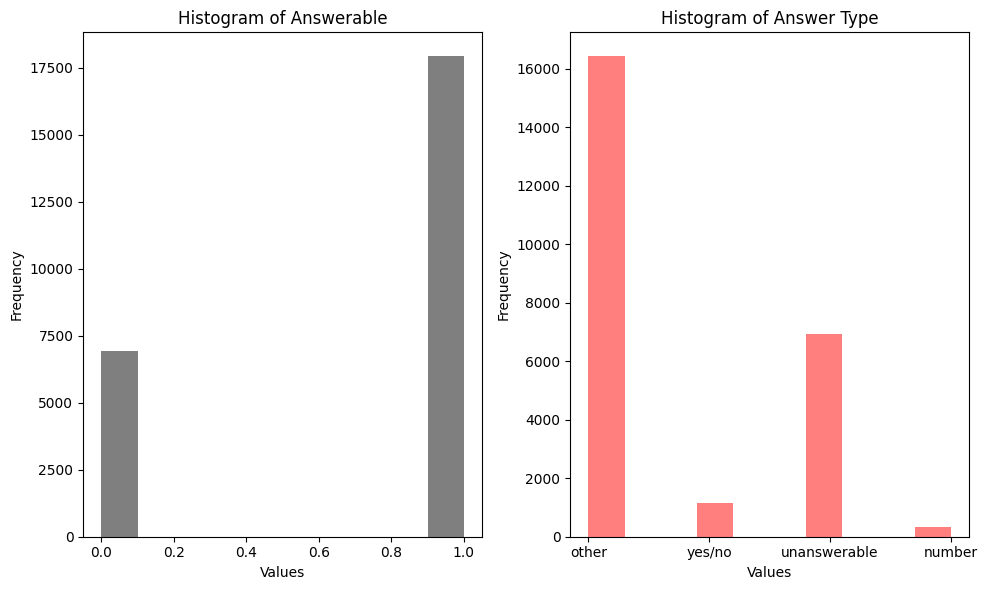

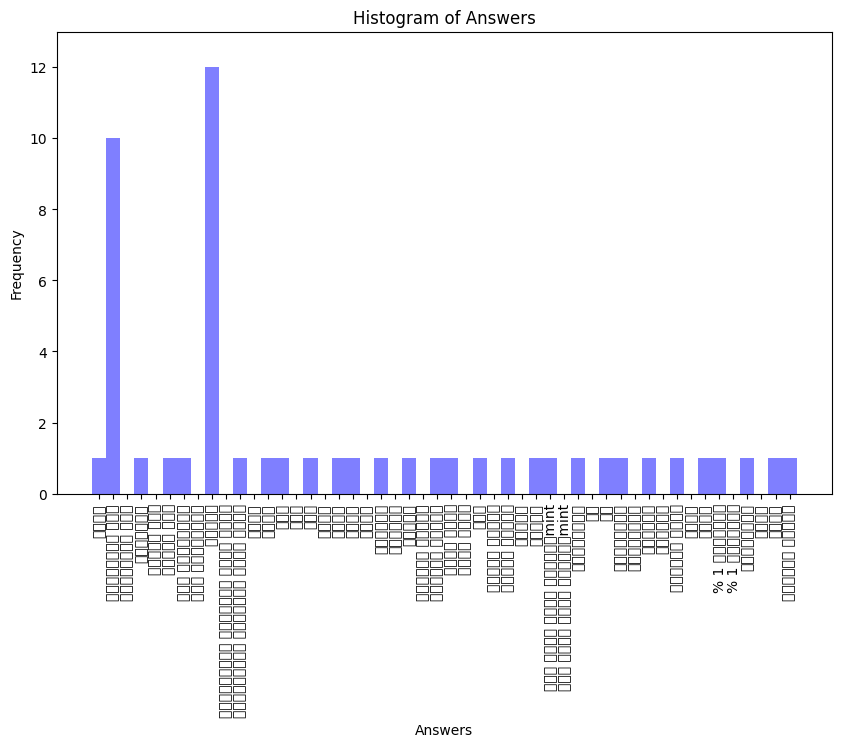

In [13]:

import matplotlib.pyplot as plt
#Create a figure with six subplots
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 6))

# Plot histogram for 'answerable' with a different color
ax1.hist(pd.concat((train_df,val_df),axis = 0)['answerable'], bins=10, alpha=0.5, color='black', align='mid')
ax1.set_title('Histogram of Answerable')
ax1.set_xlabel('Values')
ax1.set_ylabel('Frequency')

# Plot histogram for 'answer_type' with a different color
ax2.hist(pd.concat((train_df,val_df),axis = 0)['answer_type'], bins=10, alpha=0.5, color='red', align='mid')
ax2.set_title('Histogram of Answer Type')
ax2.set_xlabel('Values')
ax2.set_ylabel('Frequency')

fig.tight_layout()

# Display the plot
plt.show()

# Create the histogram
plt.figure(figsize=(10, 6))  # Adjust the figure size as per your preference
counts, bins, patches = plt.hist(data_df.sample(n=50, random_state=42,replace=False)['answer'], bins=50, color='blue', alpha=0.5)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Customize the plot
plt.title('Histogram of Answers')
plt.xlabel('Answers')
plt.ylabel('Frequency')


plt.xticks(rotation=90)

plt.xticks(bin_centers)

max_count = max(counts)
plt.ylim(0, max_count + 1)
# Show the plot
plt.show()

In [14]:
ans_lb = LabelEncoder()
data_df['answer'] = ans_lb.fit_transform(data_df['answer'])
ans_type_lb = LabelEncoder()
data_df['answer_type']= ans_type_lb.fit_transform(data_df['answer_type'])

In [15]:
data_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,এই পণ্যের নাম কি?,1,1,3572
1,VizWiz_train_00000001.jpg,তুমি কি বলতে পারবে এর মধ্যে কি আছে দয়া করে?,1,1,1184
2,VizWiz_train_00000002.jpg,এটা কি সস নাকি টমেটো? ধন্যবাদ.,1,1,1994
3,VizWiz_train_00000003.jpg,এই ছবিতে ক্যাপচা কি?,1,1,1838
4,VizWiz_train_00000004.jpg,এসব কি?,1,1,4862
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,এটা কি?,1,1,4741
24838,VizWiz_val_00004315.jpg,এটা কি আধুনিক?,2,0,3025
24839,VizWiz_val_00004316.jpg,"আমি এই ব্যাটারিটা কিনব, তুমি কি মডেল আর নাম দে...",2,0,349
24840,VizWiz_val_00004317.jpg,এটা কি ধরনের মিশ্রণ?,1,1,1168


In [17]:
#import os
#os.environ['CUDA_VISIBLE_DEVICES'] = '0' 
device = "cuda" if torch.cuda.is_available() else "cpu"
#model_clip, preprocess = clip.load("ViT-L/14", device=device)

print(f'Using {device}')

Using cuda


In [25]:
from transformers import AutoTokenizer, AutoModel
import transformers

model_name = 'google/paligemma2-10b-pt-224'

# Load Model & Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name).eval()
model = AutoModel.from_pretrained(model_name,torch_dtype=torch.float16, device_map="auto")

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/paligemma2-10b-pt-224.
401 Client Error. (Request ID: Root=1-67da5e14-56bacbfd6bab98c57e2c8729;ad2ed0ba-0511-40bf-a43a-3b244a9e6da8)

Cannot access gated repo for url https://huggingface.co/google/paligemma2-10b-pt-224/resolve/main/config.json.
Access to model google/paligemma2-10b-pt-224 is restricted. You must have access to it and be authenticated to access it. Please log in.

In [14]:
from transformers import OpenAIGPTTokenizer, OpenAIGPTModel
import torch


2025-03-19 05:43:57.764898: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 05:43:57.774100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742359437.787051 1810991 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742359437.791531 1810991 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742359437.802523 1810991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [168]:
import torch
#model_clip.context_length=512
encodings = []
for img , question in tqdm(zip(data_df['image'],data_df['question'])):
    if "train" in img:
        image = preprocess(Image.open(f'train/{img}')).unsqueeze(0).to(device)
    elif "test" in img:
       image = preprocess(Image.open(f'test/{img}')).unsqueeze(0).to(device)
    else:
        image = preprocess(Image.open(f'val/{img}')).unsqueeze(0).to(device)

    text = clip.tokenize(question,context_length=77,truncate=True).to(device)
    with torch.no_grad():
        image_encoding = model_clip.encode_image(image)
        #text_encoding = model_clip.encode_text(text)
        text_encoding = model.forward(question, tokenizer).to(device)
        #print(text_encoding.shape)
        encodings.append(torch.cat([image_encoding, text_encoding], dim=-1))

24842it [11:32, 35.86it/s]


In [169]:
torch.save(encodings,"model.pt")


In [170]:
encodings

[tensor([[-0.0983,  0.9243, -0.0143,  ...,  0.1391,  0.2733,  0.3830]],
        device='cuda:0'),
 tensor([[0.0213, 0.2233, 0.3989,  ..., 0.0165, 0.2047, 0.0485]],
        device='cuda:0'),
 tensor([[ 0.7954,  0.0384, -0.3462,  ..., -0.4720,  0.3792, -0.1359]],
        device='cuda:0'),
 tensor([[0.1859, 0.2686, 0.3157,  ..., 0.0264, 0.2875, 0.1923]],
        device='cuda:0'),
 tensor([[ 0.6831,  0.7583,  0.3733,  ...,  0.0099,  0.1172, -0.1142]],
        device='cuda:0'),
 tensor([[-0.0790,  0.9629, -0.0215,  ...,  0.0932,  0.1817, -0.1651]],
        device='cuda:0'),
 tensor([[-0.4150,  0.9102,  0.6494,  ...,  0.1359,  0.4797,  0.4997]],
        device='cuda:0'),
 tensor([[ 0.1572,  0.4639, -0.1881,  ...,  0.0630,  0.0944, -0.0784]],
        device='cuda:0'),
 tensor([[ 0.2198,  0.6104,  0.1147,  ..., -0.0411,  0.4330, -0.0558]],
        device='cuda:0'),
 tensor([[-0.3062,  1.0586,  0.3672,  ..., -0.2832,  0.1585,  0.0574]],
        device='cuda:0'),
 tensor([[ 0.7427,  0.7358, -0.0

In [171]:
print(len(data_df))

24842


In [172]:
# Generate the indices for train-test split
indices = np.arange(len(data_df))

# Perform train-test split
train_indices, test_indices = train_test_split(indices, test_size=0.05, random_state=42)

In [173]:
train = data_df.iloc[train_indices] 
train = train.reset_index(drop=True)
train

,image,question,answer_type,answerable,answer
0,VizWiz_train_00017501.jpg,এর ভেতরে কি আছে?,2,0,349
1,VizWiz_val_00003817.jpg,এই সিসিটিভির ক্রমিক সংখ্যা কি?,2,0,349
2,VizWiz_train_00002858.jpg,শার্টটা কিসের?,1,1,3541
3,VizWiz_train_00004344.jpg,আমি কি দেখছি?,1,1,4229
4,VizWiz_train_00014612.jpg,আপনি কি দয়া করে আমাকে বলবেন যে এটা টিভি স্ট্য...,3,1,5120
...,...,...,...,...,...
23594,VizWiz_val_00001052.jpg,এটা কি বলে? এটা কি বলে?,2,0,3026
23595,VizWiz_train_00005390.jpg,এটা কি ধরনের সোডা?,1,1,2841
23596,VizWiz_train_00000860.jpg,বালম বি-এল-এম কি এই কন্টেইনার সম্পর্কে লিখেছে?,3,1,2514
23597,VizWiz_train_00015795.jpg,শার্টটা কি বলে?,1,1,428


In [174]:
test = data_df.iloc[test_indices]
test = test.reset_index(drop=True)
test

,image,question,answer_type,answerable,answer
0,VizWiz_train_00005163.jpg,এটা কি আলো নাকি অন্ধকার?,1,1,1502
1,VizWiz_train_00004569.jpg,থার্মোস্তা কি বলে?,2,0,3025
2,VizWiz_train_00023795.jpg,এসব কি? এটা কি?,1,1,4391
3,VizWiz_val_00000320.jpg,পর্দায় কি লেখা আছে?,1,1,1540
4,VizWiz_train_00013788.jpg,কে- মাইন,1,1,2152
...,...,...,...,...,...
1238,VizWiz_train_00003806.jpg,এই পৃষ্ঠা কী বলে?,2,0,3025
1239,VizWiz_train_00004115.jpg,এটা কিসের মডেল?,1,1,3719
1240,VizWiz_train_00004547.jpg,এই খাবারের নাম কি?,1,1,2545
1241,VizWiz_train_00019406.jpg,এই বাক্সে কি আছে?,2,0,349


In [175]:
embedding_size = 768#encodings[0].shape[1] #change by Arif old was 768
classes = len(np.unique(ans_lb.classes_))
aux_classes = len(np.unique(train['answer_type']))
BATCH_SIZE = 64

In [176]:
classes, aux_classes

(5642, 4)

In [177]:
#encd = torch.cat([torch.load('encALL.pt')])
encd = torch.load('model.pt')                             

/tmp/ipykernel_707802/2292406867.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encd = torch.load('model.pt')


In [180]:
class dataset(Dataset):
    def __init__(self, indices, answers, types, length):
        self.indices = indices
        self.answers = answers
        self.types = types
        self.length = length

    def __getitem__(self, index):
            if self.length <= 24842:
                return encd[self.indices[index]].float() , torch.tensor(int(self.answers[index])), torch.tensor(int(self.types[index]))
            
            return encd[self.indices[index]].float() , torch.tensor(int(self.answers[index % (self.length/2)])), torch.tensor(int(self.types[index % (self.length/2)]))
            
    def __len__(self):
          return self.length

In [26]:
#val = data_df.iloc[24842:].reset_index(drop=True)
#val
#train_indices_aug = train_indices + 24842

In [182]:
e=torch.cat(encodings).cpu().numpy()
#trainDataset = dataset(np.concatenate((train_indices, train_indices_aug)), train['answer'], train['answer_type'], len(train_indices)*2)
trainDataset = dataset(np.array(range(train_indices.size)), train['answer'] , train['answer_type'], len(train_indices))

valDataset = dataset(np.array(range(test_indices.size)), test['answer'], test['answer_type'], len(test_indices))

#valDataset = dataset(np.array(list(range(encd.shape[0] - 5642, encd.shape[0]))), val['answer'], val['answer_type'], 4319)
#valDataset = dataset(np.array(list(range(encd.shape[0] - 5642, encd.shape[0]))), pd.DataFrame(e).iloc[24842:], val['answer_type'], 5642)

train_dataloader = DataLoader(trainDataset, batch_size = BATCH_SIZE, shuffle = True, num_workers=0)

val_dataloader = DataLoader(valDataset, batch_size = BATCH_SIZE, shuffle = True, num_workers=0)

In [183]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        
        self.ln1 = nn.LayerNorm(embedding_size*2)
        #self.ln1 = nn.LayerNorm(normalized_shape=[1536])
        self.dp1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(embedding_size* 2, 512)
        
        self.ln2 = torch.nn.LayerNorm(512)
        self.dp2 = torch.nn.Dropout(0.5)
        
        self.fc2 = torch.nn.Linear(512, classes)
        
        self.fc_aux = torch.nn.Linear(512, aux_classes)
        
        self.lnaux = torch.nn.LayerNorm(aux_classes)
        self.dpaux = torch.nn.Dropout(0.5)
                
        self.fc_gate = torch.nn.Linear(aux_classes, classes)
        self.act_gate = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.ln1(x)
        x = self.dp1(x)
        
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        
        x = self.ln2(x)
        x = self.dp2(x)
        
#         aux
        aux = self.fc_aux(x)
#         aux = self.lnaux(aux)
#         aux = self.dpaux(aux)
        
#         linear bottom
        vqa = self.fc2(x)
        
        output = vqa * self.act_gate(self.fc_gate(aux))
        
        
        return output,aux

In [184]:
def run_model(model,dataloader,val_loader, optimizer,train = True ):
    if train:
        model.train()
    
    loss = nn.CrossEntropyLoss()
    
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    total_correct_ty = 0
    total_samples_ty = 0
    
    for (data, ans , ans_type) in tqdm(dataloader):
        data = data.to(device)
        ans = ans.to(device)
        ans_type = ans_type.to(device)
        optimizer.zero_grad()
        output , aux = model(data)
        
        loss_ans = loss(output, ans)
        loss_type = loss(aux,ans_type)
        loss_combined=loss_ans+loss_type
        total_loss += loss_combined.item()
        loss_combined.backward()
        optimizer.step()
        
        
#         Answer Accurracy
        _, predicted_labels = torch.max(output, dim=1)
        correct = (predicted_labels == ans).sum().item()
        total_correct += correct
        total_samples += ans.size(0)
        train_accuracy = total_correct / total_samples
        
#         Type Accuracy
        _, predicted_labels_ty = torch.max(aux, dim=1)
        correct_ty = (predicted_labels_ty == ans_type).sum().item()
        total_correct_ty += correct_ty
        total_samples_ty += ans_type.size(0)
        train_accuracy_ty = total_correct_ty / total_samples_ty
    
    total_train_accuracy = (train_accuracy + train_accuracy_ty) / 2
        
        
    if val_loader is not None:
        model.eval()

    # Initialize validation-specific variables
    val_loss = 0.0
    total_correct_val=0
    total_samples_val=0
    
    total_correct_val_ty=0
    total_samples_val_ty=0
    
    # Disable gradient calculation
    with torch.no_grad():
        # Iterate over the validation data
        for (data, ans , ans_type) in val_loader:
            data = data.to(device)
            ans = ans.to(device)
            ans_type = ans_type.to(device)
            
            # Forward pass
            output , aux = model(data)

            # Compute the loss
            loss_ans = loss(output, ans)
            loss_type = loss(aux,ans_type)
            loss_combined=loss_ans+loss_type
            val_loss += loss_combined.item()

            # Update validation metrics
            _, val_predicted = torch.max(output, dim=1)
            correct_val = (val_predicted == ans).sum().item()
            total_correct_val += correct_val
            total_samples_val += ans.size(0)
            val_accuracy = total_correct_val / total_samples_val
            
            _, val_predicted_ty = torch.max(aux, dim=1)
            correct_val_ty = (val_predicted_ty == ans_type).sum().item()
            total_correct_val_ty += correct_val_ty
            total_samples_val_ty += ans_type.size(0)
            val_accuracy_ty = total_correct_val_ty / total_samples_val_ty
        
        total_val_accuracy = (val_accuracy + val_accuracy_ty) / 2
        
    train_loss = total_loss/len(dataloader)
    val_loss = val_loss/len(val_loader)
    
    print(f"\nTrain Loss: {train_loss:.4f} | AVG Train ACC: {total_train_accuracy * 100:.4f}% | Val Loss: {val_loss:.4f} | AVG Val ACC: {total_val_accuracy * 100:.2f}%")
    
    print(f"\nTrain ANS ACC: {train_accuracy * 100:.4f}% | VAL ANS ACC: {val_accuracy * 100:.4f}% | Train TYPE ACC: {train_accuracy_ty * 100:.4f}% | VAL TYPE ACC: {val_accuracy_ty * 100:.2f}%\n")
        
    return train_loss, val_loss


In [185]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Model()
model = model.to(device)
model = nn.DataParallel(model)

epoch = 125
training_loss = []
val_loss = []

optimizer = torch.optim.Adam(model.parameters(),1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=.1, threshold=1e-6)

early_stopping_patience = 15  # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_without_improvement = 0

for e in range(epoch):
    print(f'Epoch: {e+1}', f'| LR: { optimizer.param_groups[0]["lr"] }')
    trLoss, vlLoss = run_model(model,train_dataloader,val_dataloader,optimizer)    
    training_loss.append(trLoss)
    val_loss.append(vlLoss)
    
    scheduler.step(vlLoss)
    
    # Check if validation loss has improved
    if vlLoss < best_val_loss:
        best_val_loss = vlLoss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Check if early stopping criteria met
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\nValidation loss hasn't improved for {early_stopping_patience} epochs. Early stopping.")
        break

Epoch: 1 | LR: 0.001


100%|████████████████████████████████████████| 369/369 [00:00<00:00, 640.96it/s]



Train Loss: 7.2232 | AVG Train ACC: 40.9827% | Val Loss: 6.9381 | AVG Val ACC: 42.56%

Train ANS ACC: 17.5601% | VAL ANS ACC: 18.6645% | Train TYPE ACC: 64.4053% | VAL TYPE ACC: 66.45%

Epoch: 2 | LR: 0.001


100%|████████████████████████████████████████| 369/369 [00:00<00:00, 778.91it/s]



Train Loss: 7.0136 | AVG Train ACC: 42.1713% | Val Loss: 7.0617 | AVG Val ACC: 42.56%

Train ANS ACC: 18.2762% | VAL ANS ACC: 18.6645% | Train TYPE ACC: 66.0664% | VAL TYPE ACC: 66.45%

Epoch: 3 | LR: 0.001


...


Train Loss: 4.8993 | AVG Train ACC: 44.1650% | Val Loss: 8.6350 | AVG Val ACC: 42.28%

Train ANS ACC: 22.2213% | VAL ANS ACC: 18.1014% | Train TYPE ACC: 66.1087% | VAL TYPE ACC: 66.45%

Epoch: 15 | LR: 1e-05


100%|████████████████████████████████████████| 369/369 [00:00<00:00, 797.91it/s]



Train Loss: 4.8970 | AVG Train ACC: 44.2625% | Val Loss: 8.5235 | AVG Val ACC: 42.32%

Train ANS ACC: 22.3908% | VAL ANS ACC: 18.1818% | Train TYPE ACC: 66.1342% | VAL TYPE ACC: 66.45%

Epoch: 16 | LR: 1e-05


100%|████████████████████████████████████████| 369/369 [00:00<00:00, 756.18it/s]


Train Loss: 4.8774 | AVG Train ACC: 44.2307% | Val Loss: 8.6325 | AVG Val ACC: 42.40%

Train ANS ACC: 22.3654% | VAL ANS ACC: 18.3427% | Train TYPE ACC: 66.0960% | VAL TYPE ACC: 66.45%


Validation loss hasn't improved for 15 epochs. Early stopping.


In [186]:
testDataset = dataset(test_indices,test['answer'], test['answer_type'],1027)
test_dataloader = DataLoader(testDataset, batch_size=BATCH_SIZE , shuffle=True, num_workers=0)

In [187]:
loss = nn.CrossEntropyLoss()
model.eval()
test_loss = 0.0
total_correct_test=0
total_samples_test=0
    
total_correct_test_ty=0
total_samples_test_ty=0

# Disable gradient calculation
with torch.no_grad():
    # Iterate over the validation data
    for (data, ans , ans_type) in test_dataloader:
            data = data.to(device)
            ans = ans.to(device)
            ans_type = ans_type.to(device)
            # Forward pass
            output , aux = model(data)

            # Compute the loss
            loss_ans = loss(output, ans)
            loss_type = loss(aux,ans_type)
            loss_combined=loss_ans+loss_type
            test_loss += loss_combined.item()

            # Update validation metrics
            _, test_predicted = torch.max(output, dim=1)
            correct_test = (test_predicted == ans).sum().item()
            total_correct_test += correct_test
            total_samples_test += ans.size(0)
            test_accuracy = total_correct_test / total_samples_test
            
            _, test_predicted_ty = torch.max(aux, dim=1)
            correct_test_ty = (test_predicted_ty == ans_type).sum().item()
            total_correct_test_ty += correct_test_ty
            total_samples_test_ty += ans_type.size(0)
            test_accuracy_ty = total_correct_test_ty / total_samples_test_ty
        
    total_test_accuracy = (test_accuracy + test_accuracy_ty) / 2
        
        
print(f"Test TYPE ACC: {test_accuracy_ty * 100:.4f}% | Test ANS ACC: {test_accuracy * 100:.4f}% | AVG Test ACC: {total_test_accuracy * 100:.4f}% | Test Loss: {test_loss:.4f}")   

Test TYPE ACC: 67.0886% | Test ANS ACC: 16.2610% | AVG Test ACC: 41.6748% | Test Loss: 149.0273


In [188]:
e=torch.cat(encodings).cpu().numpy()
print(e)
pd.DataFrame(e).iloc()

[[-0.09832764  0.9243164  -0.01431274 ...  0.13910964  0.27331582
   0.38295078]
 [ 0.02130127  0.2232666   0.39892578 ...  0.01653972  0.20467265
   0.04847297]
 [ 0.79541016  0.03839111 -0.3461914  ... -0.4719818   0.37916088
  -0.13593018]
 ...
 [ 0.3515625   0.5205078   0.2524414  ...  0.05646535  0.3990946
   0.23527835]
 [ 0.3491211  -0.41015625 -0.2763672  ...  0.27435237  0.1413216
   0.22596169]
 [-0.06799316  0.050354    0.00961304 ... -0.585228    0.29375252
  -0.04904192]]


In [189]:
pd.DataFrame(e).iloc()[1]

0       0.021301
1       0.223267
2       0.398926
3       0.007046
4      -0.393799
          ...   
1531    0.287089
1532   -0.141222
1533    0.016540
1534    0.204673
1535    0.048473
Name: 1, Length: 1536, dtype: float32

In [190]:
range(train_indices.size)

range(0, 23599)